# Evaluación y Optimización del Modelo IA - Julio Encalada y Sara Cruz

## Proyecto

**Robot Educativo basado en Visión Artificial para apoyar la Comprensión Lectora en Educación General Básica**

**Estudiantes:** Julio Encalada y Sara Cruz  

**Modelo de visión artificial:** YOLOv8

In [9]:
# ==========================================================
# INSTALACIÓN DE LIBRERÍAS
# ==========================================================

!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.5 MB/s eta 0:00:00


In [10]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Ld5MA3ZSF8L57FTpRsFu")
project = rf.workspace("julios-workspace-3vccd").project("primerodebasica")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PrimeroDeBasica-1 in yolov8:: 100%|██████████| 846/846 [00:00<00:00, 8625.93it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
import os

dataset_path = "/content/PrimeroDeBasica-1/data.yaml"

print("¿Existe el data.yaml?:", os.path.exists(dataset_path))
print(dataset_path)

¿Existe el data.yaml?: True
/content/PrimeroDeBasica-1/data.yaml


In [12]:
import os

print(os.path.exists("/content/PrimeroDeBasica-1"))
print(os.path.exists("/content/PrimeroDeBasica-1/data.yaml"))

True
True


In [28]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results_40 = model.train(
    data="/content/PrimeroDeBasica-1/data.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    cache=True,
    project="Evaluacion_Modelo_IA",
    name="YOLOv8n_40Epocas",
    exist_ok=True,
    verbose=True
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PrimeroDeBasica-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_40Epocas, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/PrimeroDeBasica-1/data.yaml",
    epochs=80,
    patience=15,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    cache=True,
    project="Evaluacion_Modelo_IA",
    name="YOLOv8n_80Epocas_EarlyStopping",
    exist_ok=True,
    verbose=True
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PrimeroDeBasica-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_80Epocas_EarlyStopping, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

In [14]:
import os

ruta = "/content/runs/detect"

for root, dirs, files in os.walk(ruta):
    print(root)

/content/runs/detect
/content/runs/detect/Evaluacion_Modelo_IA
/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping
/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/weights


In [15]:
import os

ruta = "/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping"

for archivo in sorted(os.listdir(ruta)):
    print(archivo)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch1680.jpg
train_batch1681.jpg
train_batch1682.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
weights


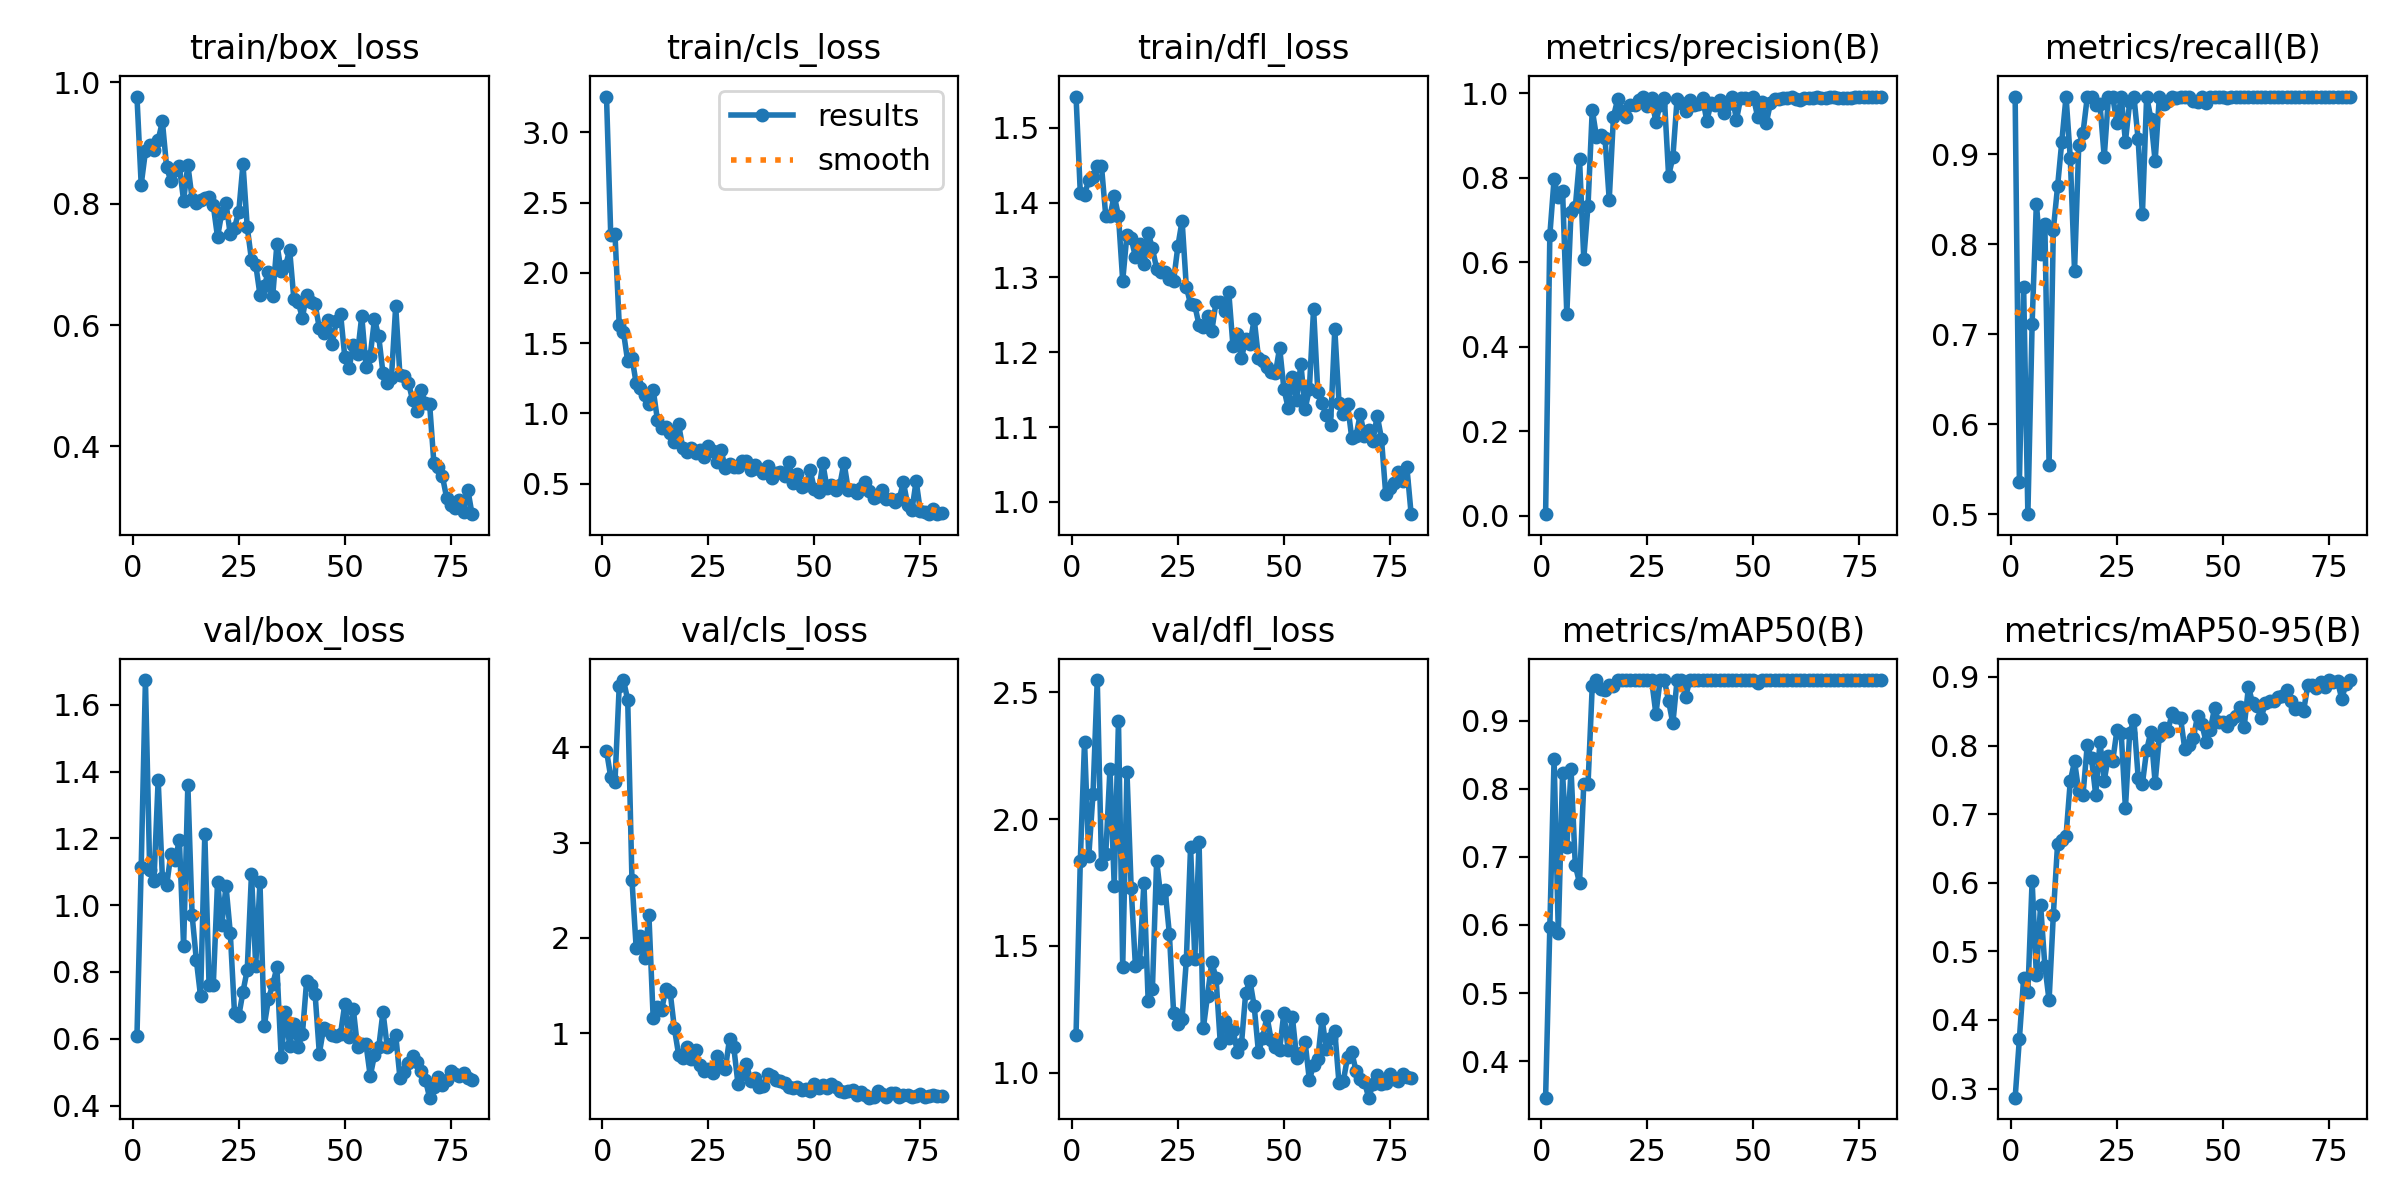

In [16]:
from IPython.display import Image, display

display(Image("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/results.png"))

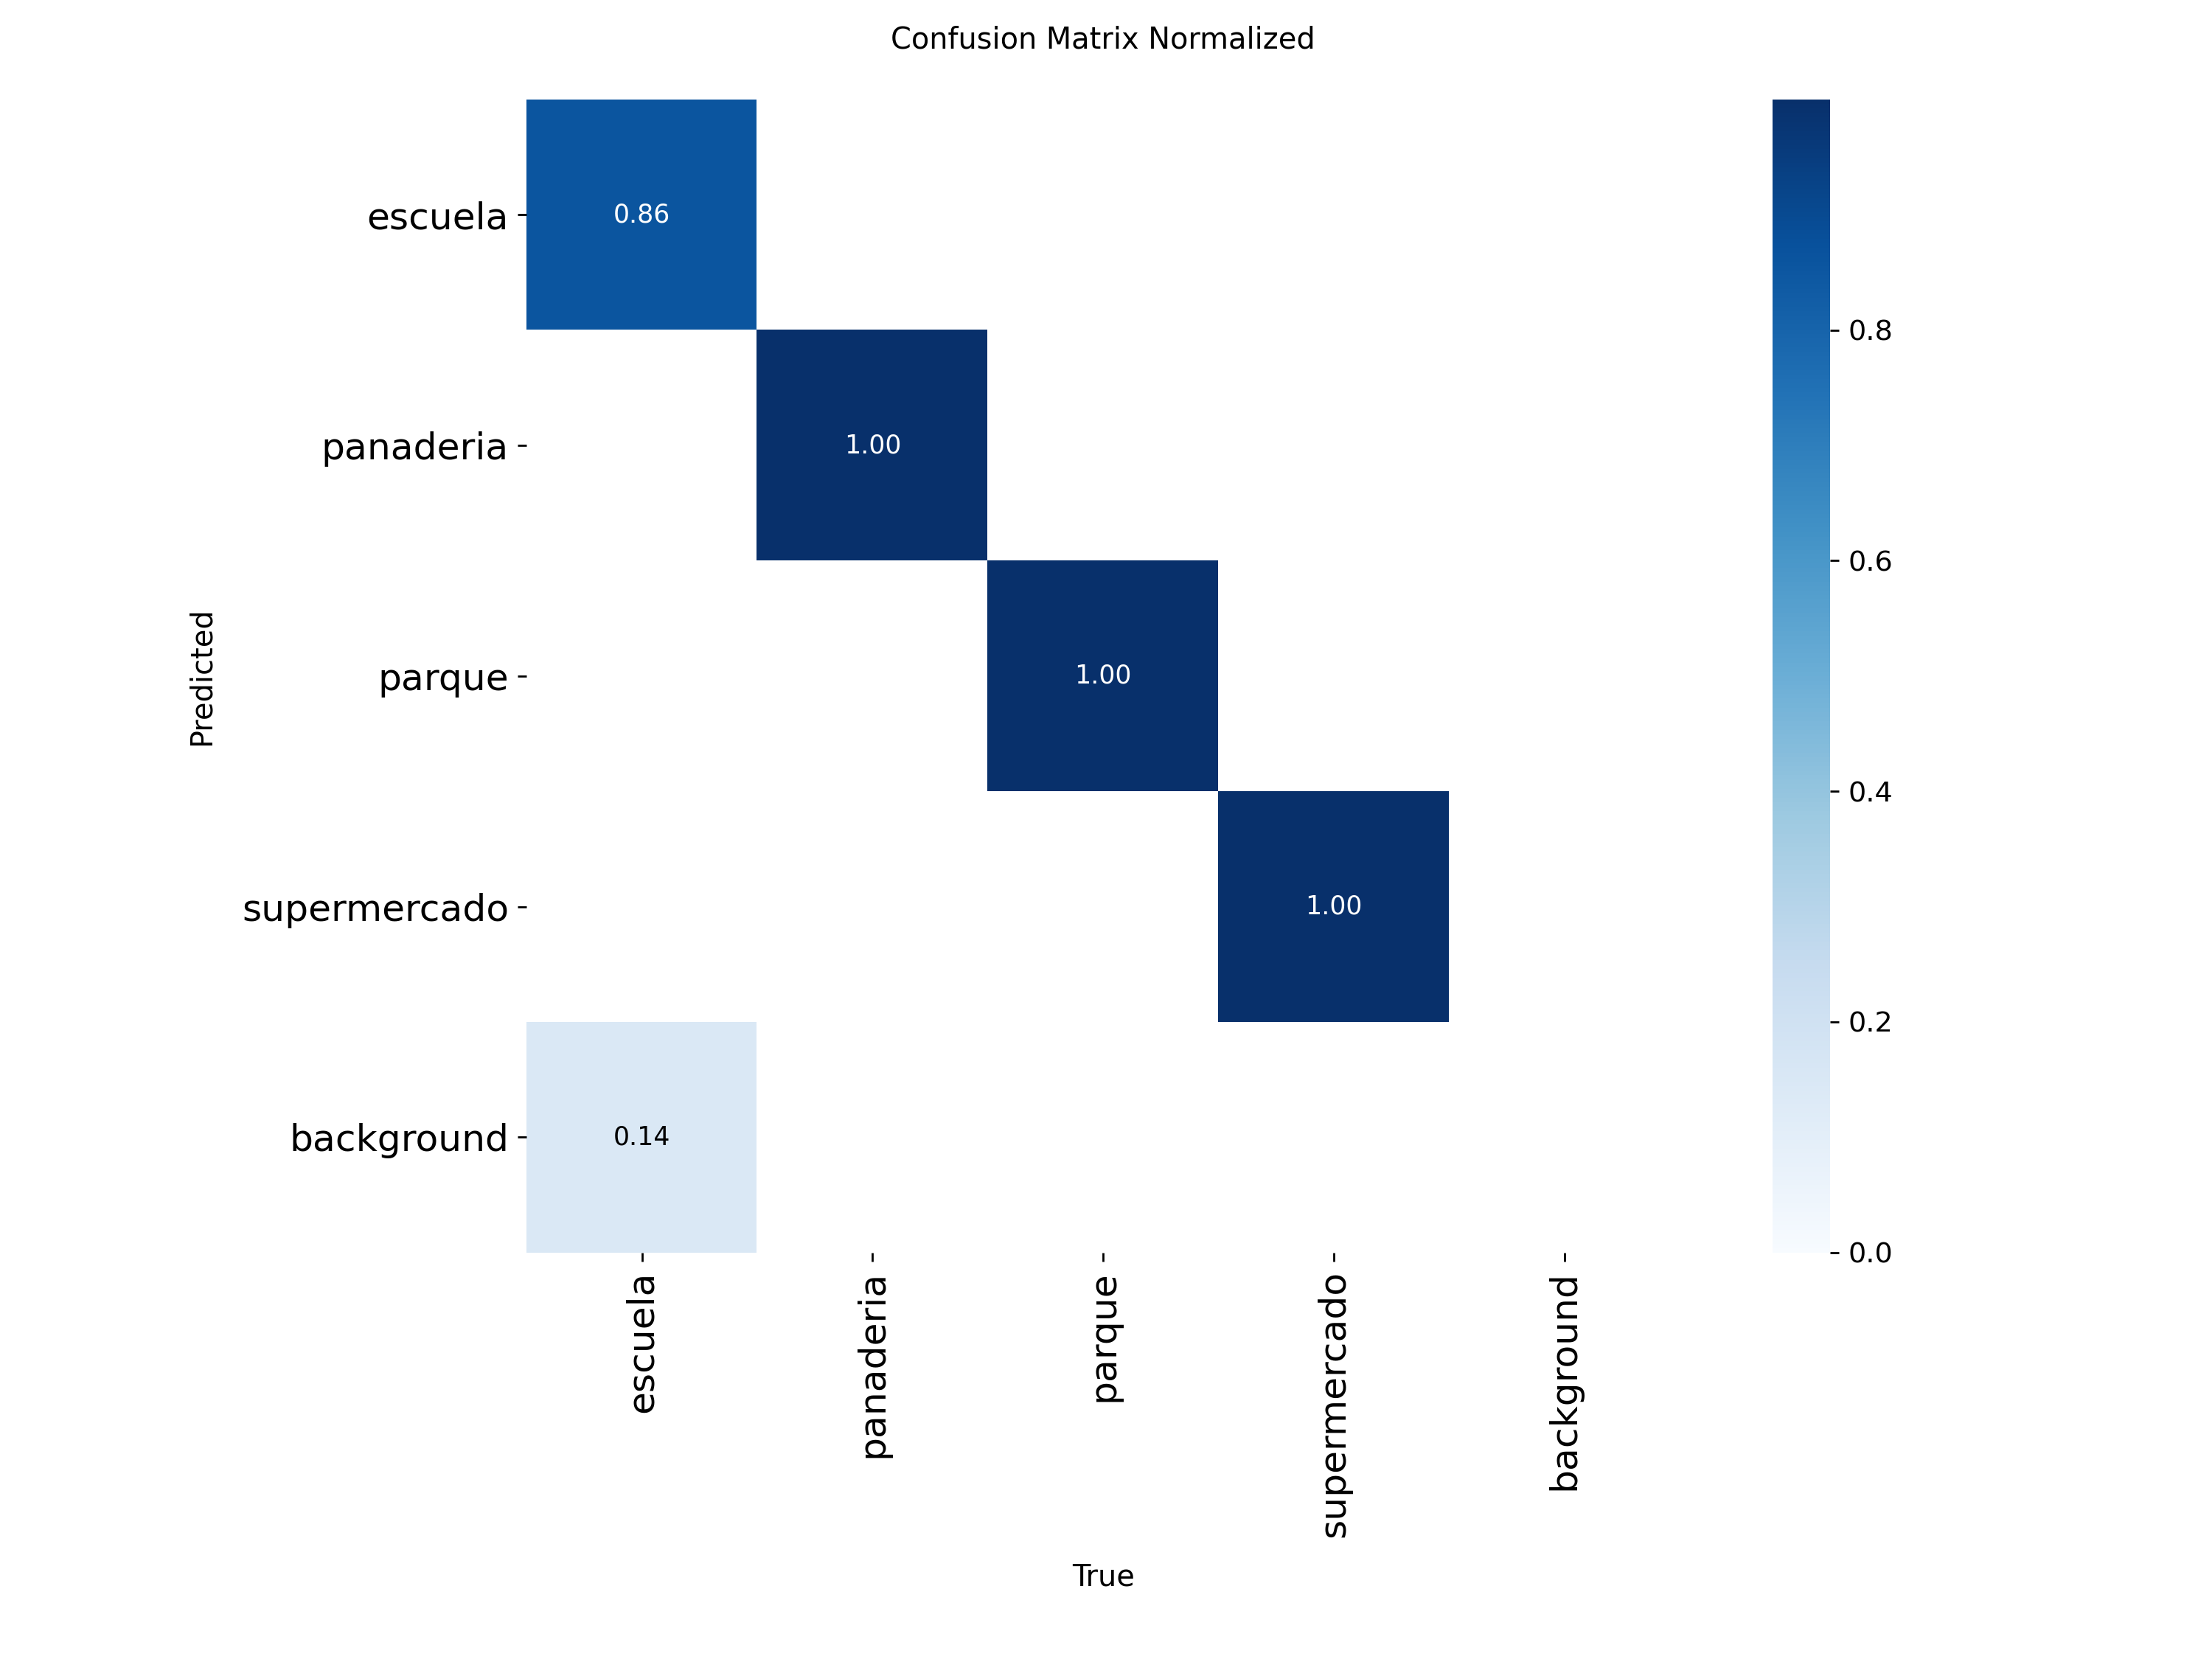

In [17]:
from IPython.display import Image, display

display(Image("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/confusion_matrix_normalized.png"))

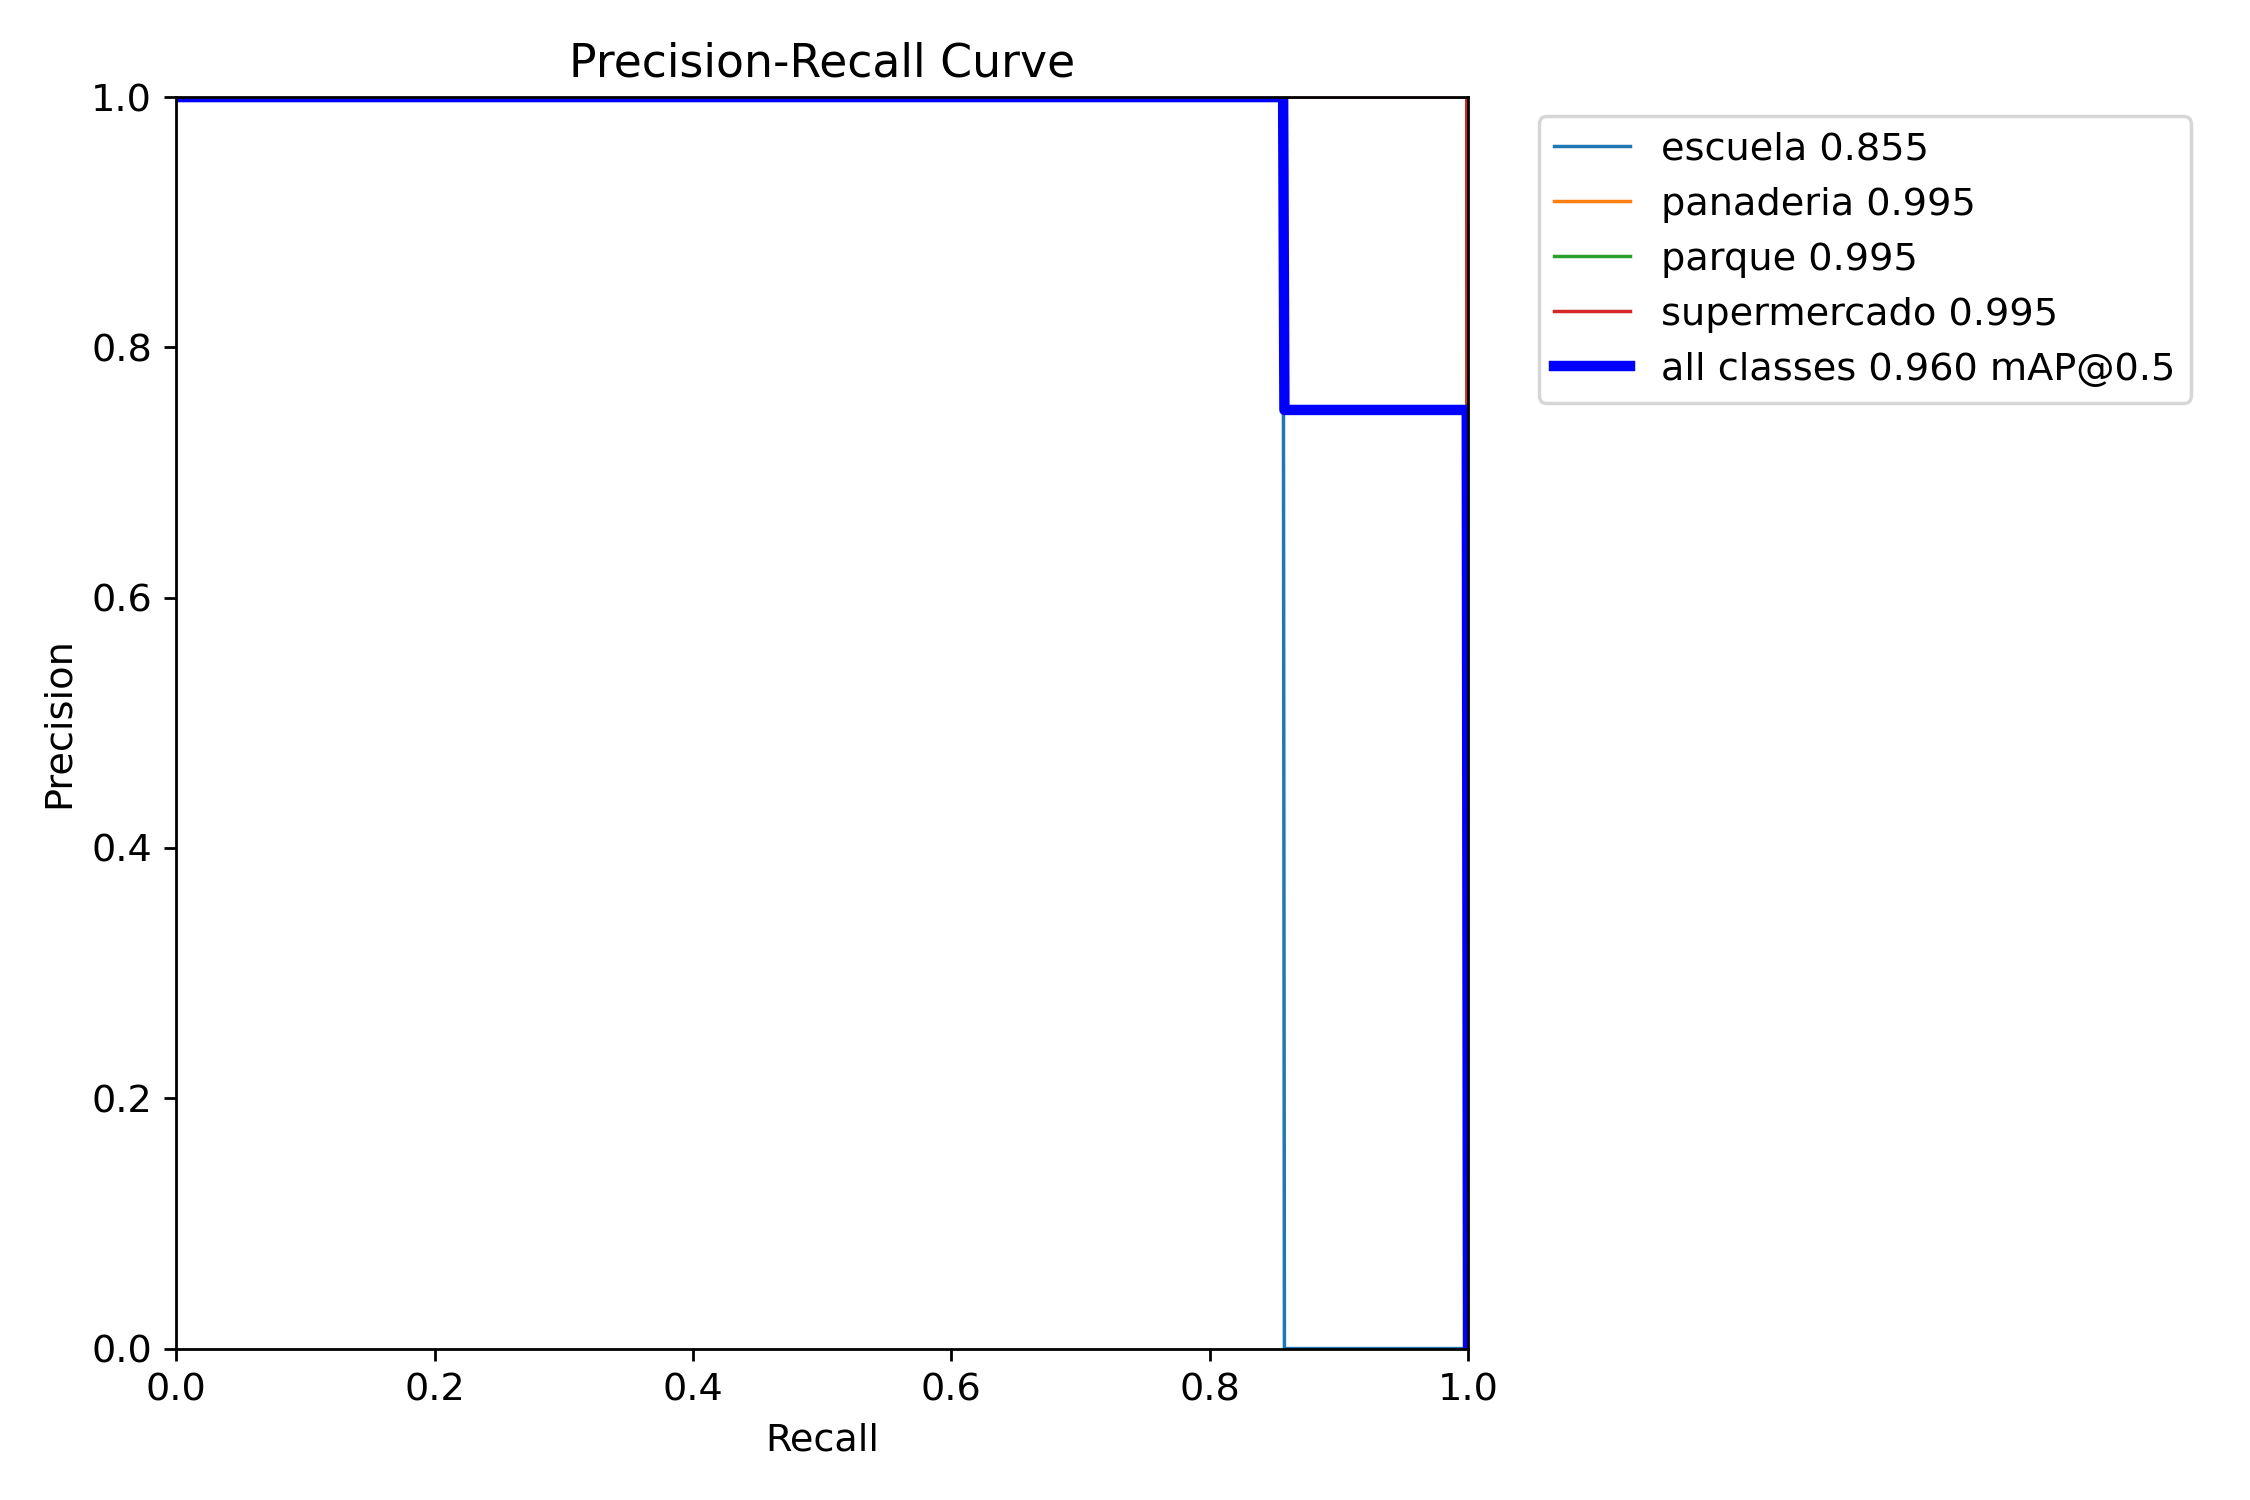

In [18]:
from IPython.display import Image, display

display(Image("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/BoxPR_curve.png"))

In [19]:
import os

ruta = "/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping"

for archivo in sorted(os.listdir(ruta)):
    if "curve" in archivo.lower():
        print(archivo)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png


In [21]:
from IPython.display import Image, display

display(Image("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/F1_curve.png"))

FileNotFoundError: No such file or directory: '/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/F1_curve.png'

FileNotFoundError: No such file or directory: '/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/F1_curve.png'

<IPython.core.display.Image object>

In [22]:
import os

ruta = "/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping"

for archivo in sorted(os.listdir(ruta)):
    if "curve" in archivo.lower():
        print(archivo)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png


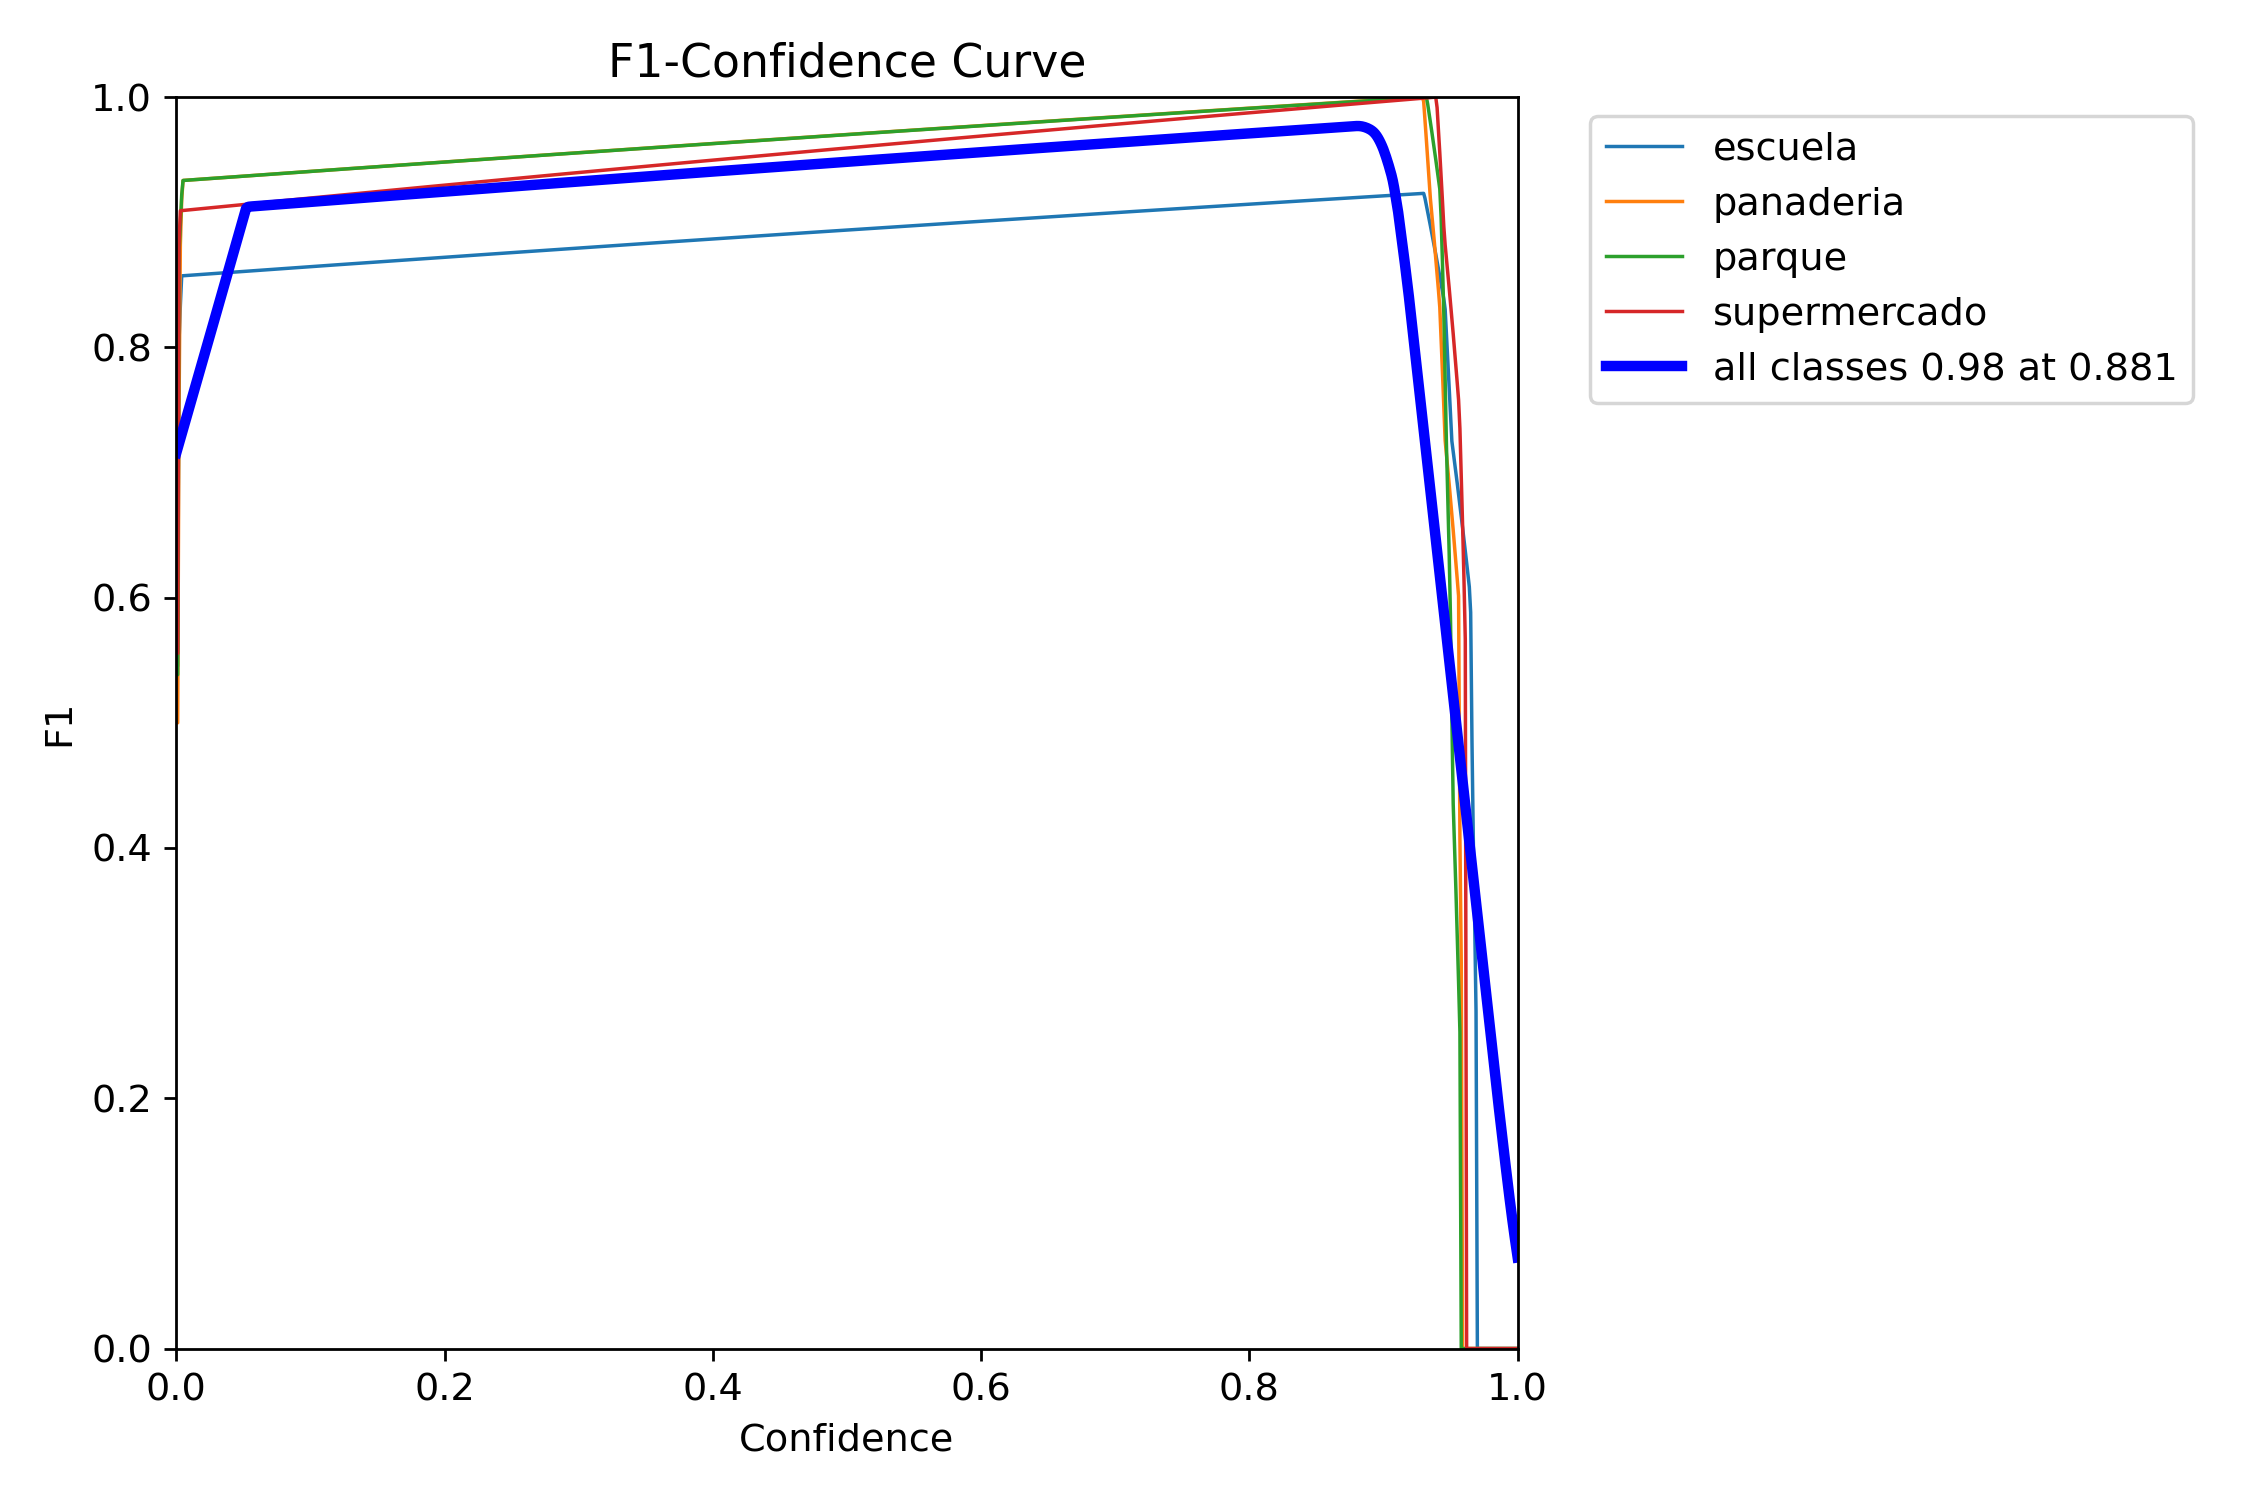

In [23]:
from IPython.display import Image, display

display(Image("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/BoxF1_curve.png"))

In [24]:
import os

for root, dirs, files in os.walk("/content/runs/detect"):
    print(root)

/content/runs/detect
/content/runs/detect/Evaluacion_Modelo_IA
/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping
/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/weights


In [25]:
import os

ruta = "/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping"

for archivo in sorted(os.listdir(ruta)):
    print(archivo)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch1680.jpg
train_batch1681.jpg
train_batch1682.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
weights


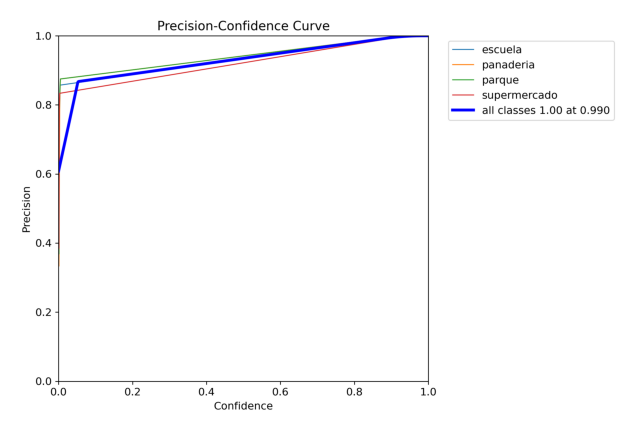

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/BoxP_curve.png")

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.show()

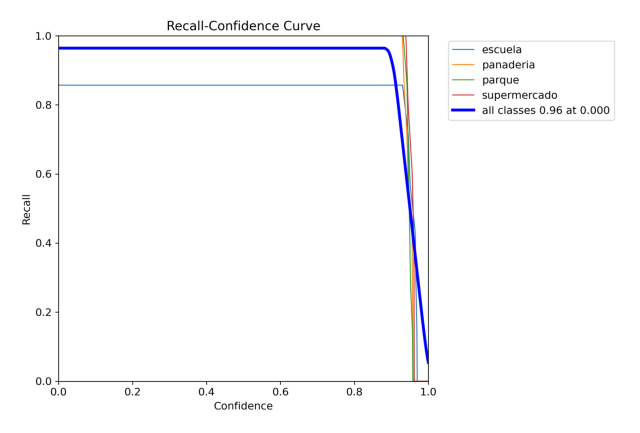

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/BoxR_curve.png")

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [29]:
from google.colab import files

files.download("/content/runs/detect/Evaluacion_Modelo_IA/YOLOv8n_80Epocas_EarlyStopping/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>